In [6]:
import pandas as pd

df = pd.read_csv('../data/raw/FR_Dataset.csv')
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  str    
 1   rating    40432 non-null  float64
 2   label     40432 non-null  str    
 3   text_     40432 non-null  str    
dtypes: float64(1), str(3)
memory usage: 1.2 MB


In [9]:
df.shape

(40432, 4)

In [11]:
df['label'].value_counts() # shows class balance

label
CG    20216
OR    20216
Name: count, dtype: int64

In [12]:
df.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

In [14]:
df['text_length'] = df['text_'].apply(len)

In [15]:
df['text_length'].describe()

count    40432.000000
mean       351.271963
std        369.813570
min         24.000000
25%        107.000000
50%        198.000000
75%        439.000000
max       2827.000000
Name: text_length, dtype: float64

In [17]:
df.groupby('label')['rating'].value_counts(normalize = True)

label  rating
CG     5.0       0.609369
       4.0       0.193906
       3.0       0.096557
       1.0       0.052582
       2.0       0.047586
OR     5.0       0.605461
       4.0       0.200089
       3.0       0.090720
       1.0       0.054017
       2.0       0.049713
Name: proportion, dtype: float64

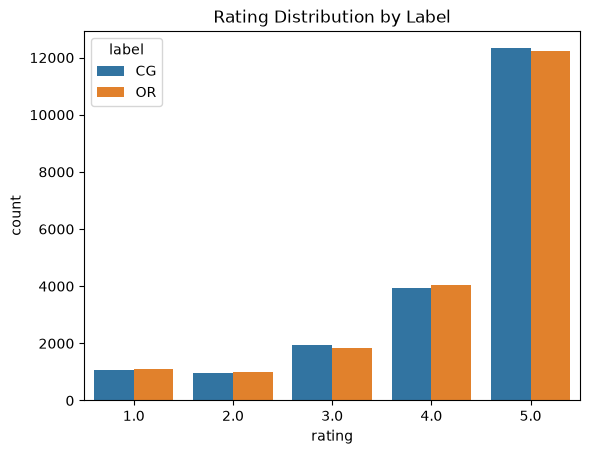

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data = df , x = 'rating' , hue = 'label')
plt.title('Rating Distribution by Label')
plt.show()

In [23]:
df.groupby('label')['text_length'].describe() 
# tells us if fake reviews are noticebly longer or shorter than the real (OR) ones -sometimes AI gen text has a different length pattern

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
CG,20216.0,305.573506,307.037430,24.0,96.0,174.0,383.0,1717.0
OR,20216.0,396.970419,418.428047,28.0,121.0,224.0,498.0,2827.0
